In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Libraries imported successfully
Pandas: 3.0.3
NumPy: 2.4.6


In [6]:
# Load all three CSV files
print("📂 Loading Elliptic Bitcoin Dataset...\n")

# Features (166 features + transcaction ID)
features_df = pd.read_csv("../data/elliptic/elliptic_txs_features.csv", header=None)
print(f"✅ Features loaded: {features_df.shape}")

# Labels (transaction ID + class)
labels_df = pd.read_csv("../data/elliptic/elliptic_txs_classes.csv")
print(f"✅ Labels loaded: {labels_df.shape}")

# Edges (transaction connections)
edges_df = pd.read_csv("../data/elliptic/elliptic_txs_edgelist.csv")
print(f"✅ Edges loaded: {edges_df.shape}")

print("\n" + "=" * 60)
print("Dataset loaded successfully.")
print("=" * 60)

📂 Loading Elliptic Bitcoin Dataset...

✅ Features loaded: (203769, 167)
✅ Labels loaded: (203769, 2)
✅ Edges loaded: (234355, 2)

Dataset loaded successfully.


In [7]:
print("🔍 FEATURES DATAFRAME")
print("=" * 60)
print(f"Shape: {features_df.shape}")
print(f"Columns: {features_df.shape[1]}(Column 0 = txId, Column 1 = timestep, Columns 2-166 = features)")
print("\nFirst 5 rows:")
print(features_df.head())

print("\n📊 Basic Statistics (first 10 features):")
print(features_df.iloc[:, 1:11].describe())

🔍 FEATURES DATAFRAME
Shape: (203769, 167)
Columns: 167(Column 0 = txId, Column 1 = timestep, Columns 2-166 = features)

First 5 rows:
         0    1         2         3         4          5         6    \
0  230425980    1 -0.171469 -0.184668 -1.201369  -0.121970 -0.043875   
1    5530458    1 -0.171484 -0.184668 -1.201369  -0.121970 -0.043875   
2  232022460    1 -0.172107 -0.184668 -1.201369  -0.121970 -0.043875   
3  232438397    1  0.163054  1.963790 -0.646376  12.409294 -0.063725   
4  230460314    1  1.011523 -0.081127 -1.201369   1.153668  0.333276   

        7          8         9    ...       157       158       159       160  \
0 -0.113002  -0.061584 -0.162097  ... -0.562153 -0.600999  1.461330  1.461369   
1 -0.113002  -0.061584 -0.162112  ...  0.947382  0.673103 -0.979074 -0.978556   
2 -0.113002  -0.061584 -0.162749  ...  0.670883  0.439728 -0.979074 -0.978556   
3  9.782742  12.414558 -0.163645  ... -0.577099 -0.613614  0.241128  0.241406   
4  1.312656  -0.061584 -0.16

In [8]:
print("🏷️  LABELS DATAFRAME")
print("="*60)
print(f"Shape: {labels_df.shape}")
print(f"Columns:{labels_df.columns.to_list()}")
print("\nFirst 10 rows:")
print(labels_df.head(10))

print("\n📊 Class Distribution:")
class_counts = labels_df['class'].value_counts()
print(class_counts)
total = len(labels_df)
print("\n📈 Percentages:")
for cls, count in class_counts.items():
    print(f" {cls:8s}: {count:6,} ({count/total*100:5.2f}%)")

🏷️  LABELS DATAFRAME
Shape: (203769, 2)
Columns:['txId', 'class']

First 10 rows:
        txId    class
0  230425980  unknown
1    5530458  unknown
2  232022460  unknown
3  232438397        2
4  230460314  unknown
5  230459870  unknown
6  230333930  unknown
7  230595899  unknown
8  232013274  unknown
9  232029206        2

📊 Class Distribution:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

📈 Percentages:
 unknown : 157,205 (77.15%)
 2       : 42,019 (20.62%)
 1       :  4,545 ( 2.23%)


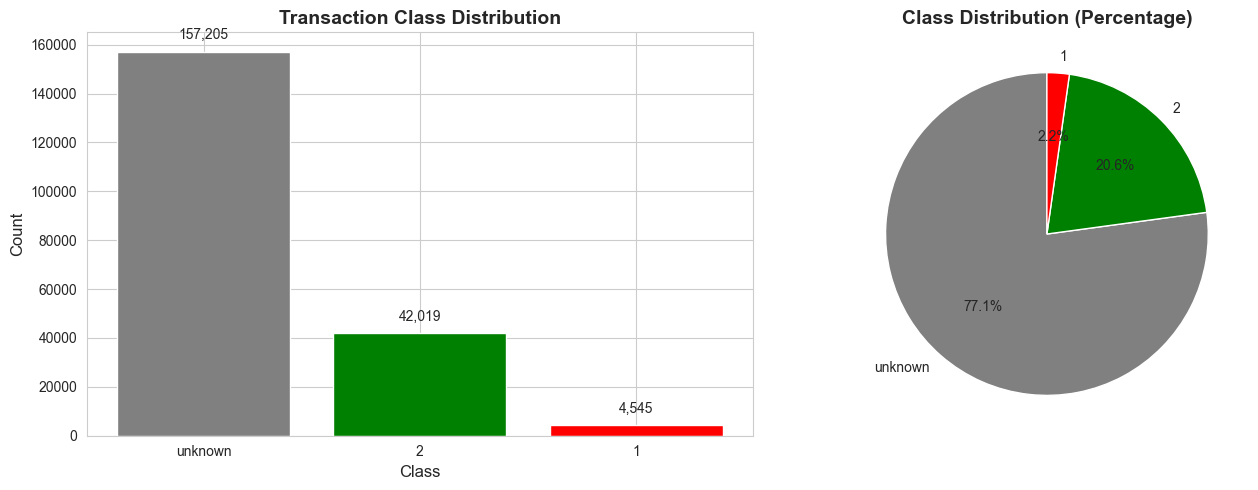


💡 INSIGHT:
Only ~2% of transactions are labeled as illicit!
This is called 'class imbalance' - we'll handle this with SMOTE later.


In [9]:
# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts = labels_df['class'].value_counts()
ax1.bar(class_counts.index, class_counts.values, color=['gray', 'green', 'red'])
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(class_counts)))
ax1.set_xticklabels(class_counts.index)

# Add count labels on bars
for i, (cls, count) in enumerate(class_counts.items()):
    ax1.text(i, count + 5000, f'{count:,}', ha='center', fontsize=10)

# Pie chart
colors = ['gray', 'green', 'red']
ax2.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT:")
print("Only ~2% of transactions are labeled as illicit!")
print("This is called 'class imbalance' - we'll handle this with SMOTE later.")

In [13]:
# Merge features with labels
print("🔗 Merging features and labels...")
features_df = features_df.rename(columns={0: 'txId'})
df = features_df.merge(labels_df, on='txId')
print(f"\n✅ Merged DataFrame Shape: {df.shape}")
print(f"Columns: {df.shape[1]}")
print("\nFirst 3 rows:")
print(df.head(3))
print(f"\n🔍 Missing values: {df.isnull().sum().sum()}")

🔗 Merging features and labels...

✅ Merged DataFrame Shape: (203769, 168)
Columns: 168

First 3 rows:
        txId  1         2         3         4        5         6         7  \
0  230425980  1 -0.171469 -0.184668 -1.201369 -0.12197 -0.043875 -0.113002   
1    5530458  1 -0.171484 -0.184668 -1.201369 -0.12197 -0.043875 -0.113002   
2  232022460  1 -0.172107 -0.184668 -1.201369 -0.12197 -0.043875 -0.113002   

          8         9  ...       158       159       160       161       162  \
0 -0.061584 -0.162097  ... -0.600999  1.461330  1.461369  0.018279 -0.087490   
1 -0.061584 -0.162112  ...  0.673103 -0.979074 -0.978556  0.018279 -0.087490   
2 -0.061584 -0.162749  ...  0.439728 -0.979074 -0.978556 -0.098889 -0.106715   

        163       164       165       166    class  
0 -0.131155 -0.097524 -0.120613 -0.119792  unknown  
1 -0.131155 -0.097524 -0.120613 -0.119792  unknown  
2 -0.131155 -0.183671 -0.120613 -0.119792  unknown  

[3 rows x 168 columns]

🔍 Missing values: 0


⏰ TIME STEP ANALYSIS (Feature 1)
Min time step: 1
Max time step: 49
Number of unique time steps: 49


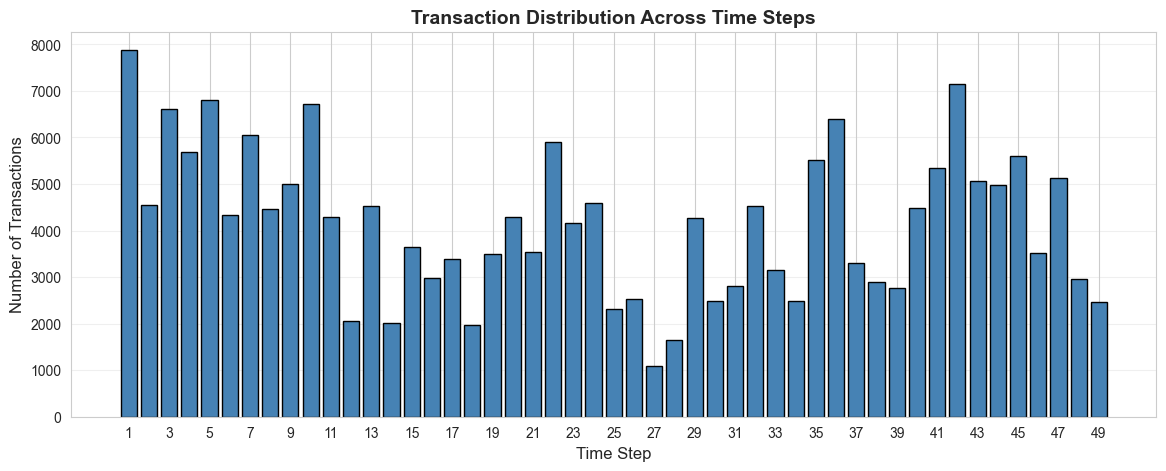


💡 INSIGHT:
Time steps 1-49 represent ~3 years of Bitcoin transactions
Each time step ≈ 2 weeks of real time


In [14]:
print("⏰ TIME STEP ANALYSIS (Feature 1)")
print("="*60)

print(f"Min time step: {df[1].min()}")
print(f"Max time step: {df[1].max()}")
print(f"Number of unique time steps: {df[1].nunique()}")

# Transactions per time step
time_dist = df[1].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(time_dist.index, time_dist.values, color='steelblue', edgecolor='black')
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.title('Transaction Distribution Across Time Steps', fontsize=14, fontweight='bold')
plt.xticks(range(1, 50, 2))
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n💡 INSIGHT:")
print("Time steps 1-49 represent ~3 years of Bitcoin transactions")
print("Each time step ≈ 2 weeks of real time")

In [17]:
labeled_df = df[df['class'] != 'unknown'].copy()
labeled_df['is_illicit'] = (labeled_df['class'] == '1').astype(int)

print("📊 LABELED DATA ANALYSIS")
print("="*60)
print(f"Total labeled transactions: {len(labeled_df):,}")
print(f"  - Illicit (class 1): {(labeled_df['is_illicit'] == 1).sum():,}")
print(f"  - Licit (class 2): {(labeled_df['is_illicit'] == 0).sum():,}")
print(f"\n⚖️  Class Imbalance Ratio: {(labeled_df['is_illicit'] == 1).sum() / (labeled_df['is_illicit'] == 0).sum():.1f}:1")
print("   (For every 1 illicit transaction, there are ~9 licit ones)")

📊 LABELED DATA ANALYSIS
Total labeled transactions: 46,564
  - Illicit (class 1): 4,545
  - Licit (class 2): 42,019
